In [ ]:
# --- Repo-root bootstrap: keep relative paths (data/..., common.validation) working
# regardless of where Jupyter's working directory starts out ---
import os, sys
from pathlib import Path

_root = Path.cwd()
while not (_root / ".git").exists() and _root.parent != _root:
    _root = _root.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


C:\Users\ilias\AppData\Local\Temp\ipykernel_22724\1531746152.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_scaled_df[cols_to_scale] = (
C:\Users\ilias\AppData\Local\Temp\ipykernel_22724\1531746152.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_scaled_df[cols_to_scale] = (
C:\Users\ilias\AppData\Local\Temp\ipykernel_22724\1531746152.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

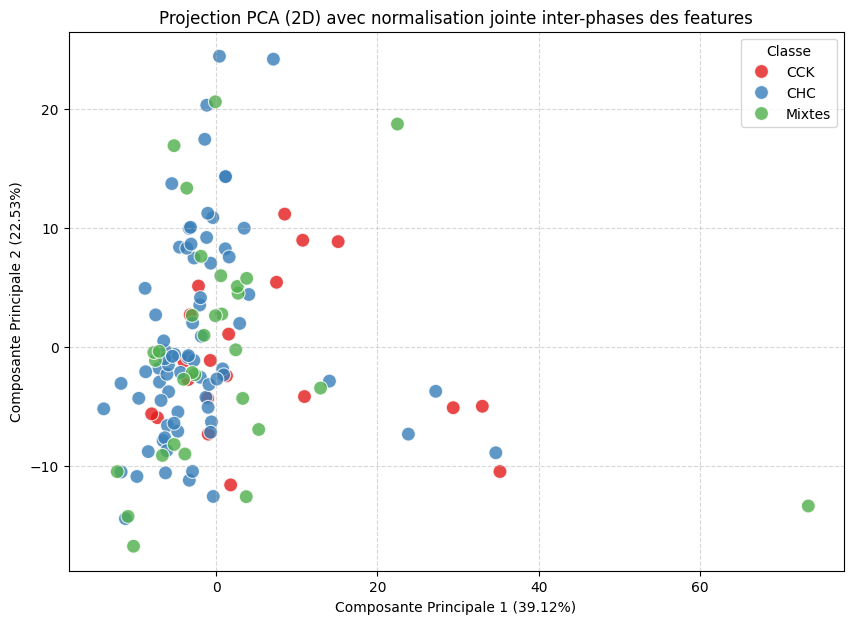

In [ ]:
"""
Les données sont normalisées ensemble selon les phases (même normalisation pour une même donnée
au long des 3 phases), et on calcule une ACP en 2 dimensions
-> pas très concluant
"""



import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_final = pd.read_csv("./data/flattened_global_scaled.csv", sep=";")

# ==========================================
# 1. PRÉPARATION ET NORMALISATION PAR BLOC DE PHASES
# ==========================================

# Extraction de la variable cible pour la coloration du graphique
labels = df_final["classe_name"]

# Liste des phases ordonnées utilisées lors du pivotement
phases = ["PORT", "ART", "TARD"]

# Identification des colonnes de métadonnées et des colonnes de features
metadata_cols = ["id", "patient_num", "classe_name"]
feature_cols = [col for col in df_final.columns if col not in metadata_cols]

# Extraction des noms de features de base (en retirant le suffixe de la phase)
# Exemple : 'original_shape_Elongation_PORT' devient 'original_shape_Elongation'
base_features = set()
for col in feature_cols:
    for phase in phases:
        if col.endswith(f"_{phase}"):
            base_features.add(col[: -len(f"_{phase}")])

# Création d'un DataFrame vide pour accueillir les données normalisées
X_scaled_df = pd.DataFrame(index=df_final.index)

# Boucle de normalisation jointe pour chaque feature de base
for base_feat in base_features:
    # On reconstruit le triplet de colonnes associé à cette feature (PORT, ART, TARD)
    cols_to_scale = [f"{base_feat}_{phase}" for phase in phases]

    # Extraction et fusion de toutes les valeurs du triplet dans une seule matrice
    combined_values = df_final[cols_to_scale].values

    # Calcul d'une unique moyenne et d'un unique écart-type pour ce bloc de données
    mean_global = combined_values.mean()
    std_global = combined_values.std()

    # Sécurité pour éviter la division par zéro si la feature est constante
    if std_global == 0:
        std_global = 1.0

    # Application de la même transformation de centrage-réduction sur les 3 colonnes simultanément
    X_scaled_df[cols_to_scale] = (
        df_final[cols_to_scale] - mean_global
    ) / std_global

# Réalignement strict de l'ordre des colonnes pour correspondre au DataFrame d'origine
X_scaled_df = X_scaled_df[feature_cols]

# ==========================================
# 2. APPLICATION DE LA PCA (2 COMPOSANTES)
# ==========================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

# Création d'un DataFrame dédié à la visualisation
df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca["classe_name"] = labels.values

# Récupération de la variance expliquée pour enrichir les axes du graphique
var_expliquee = pca.explained_variance_ratio_ * 100

# ==========================================
# 3. VISUALISATION AVEC SEABORN
# ==========================================

plt.figure(figsize=(10, 7))

# Tracé des points colorés selon la classe du patient
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="classe_name",
    palette="Set1",
    alpha=0.8,
    s=100,
)

# Configuration des labels et du titre
plt.xlabel(f"Composante Principale 1 ({var_expliquee[0]:.2f}%)")
plt.ylabel(f"Composante Principale 2 ({var_expliquee[1]:.2f}%)")
plt.title(
    "Projection PCA (2D) avec normalisation jointe inter-phases des features"
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Classe")

# Affichage du graphique
plt.show()